In [1]:
# Count the total number of enumerated key in 2_annotation.json 
import json
from pathlib import Path

def count_enumerated_keys(json_filepath: str | Path) -> int:
    path = Path(json_filepath)
    
    if not path.exists():
        print(f"File not found: {path}")
        return 0
        
    with path.open("r", encoding="utf-8") as f:
        annotations_by_paper = json.load(f)
        
    # annotations_by_paper is structured as { paper_id: { equation_key: [annotations...] } }
    # We sum the number of equation keys for each paper
    total_keys = sum(len(equations) for equations in annotations_by_paper.values())
    
    return total_keys

annotations_file = "../../data/2_annotations.json"

total = count_enumerated_keys(annotations_file)
print(f"Total number of enumerated keys in 2_annotations.json: {total}")

Total number of enumerated keys in 2_annotations.json: 834


In [5]:
annotations_file = "../../data/2_annotations.json"
equation_file = "../../data/3_equations.json"

In [11]:
import json
import re
from pathlib import Path
from collections import Counter

# Connect to the extracted equations database for the Equations Knowledge Graph
input_file = Path("../../data/3_equations.json")

data = json.loads(input_file.read_text(encoding="utf-8"))

STOPWORDS = {
    "the", "of", "and", "in", "to", "a", "is", "for", "as", "on",
    "are", "be", "this", "we", "can", "an", "it"
}

counter = Counter()

for paper_equations in data.values():
    for entry in paper_equations.values():
        window = entry.get("surrounding_text", {}).get("window", "")
        
        # Modified regex: [A-Za-z0-9_\-]{1,} ensures at least 2 characters total
        # This prevents 1-letter variables (like 'x', 'y', 'e') from skewing the candidate vocabulary
        words = re.findall(r"[A-Za-z][A-Za-z0-9_\\-]{1,}", window.lower())
        
        # Explicit length constraint to ensure all tokens added to the dictionary are multi-character concepts
        words = [word for word in words if word not in STOPWORDS and len(word) > 1]
        
        counter.update(words)

# Display the 50 most common terms to help establish anchor phrases for the Equations Knowledge Graph
counter.most_common(50)

[('equation', 526),
 ('hat', 259),
 ('state', 176),
 ('quantum', 167),
 ('mathcal', 143),
 ('text', 135),
 ('which', 123),
 ('system', 120),
 ('at', 118),
 ('two', 101),
 ('states', 98),
 ('x_', 90),
 ('hamiltonian', 85),
 ('spin', 84),
 ('time', 80),
 ('will', 80),
 ('its', 78),
 ('omega_', 77),
 ('operator', 74),
 ('pt', 72),
 ('mathrm', 69),
 ('rangle', 67),
 ('prime', 64),
 ('pgfsys', 64),
 ('classical', 63),
 ('space', 63),
 ('between', 62),
 ('not', 61),
 ('ket', 61),
 ('respectively', 60),
 ('our', 60),
 ('rho', 60),
 ('mathbb', 59),
 ('or', 59),
 ('each', 59),
 ('number', 58),
 ('first', 57),
 ('into', 56),
 ('here', 54),
 ('one', 53),
 ('function', 53),
 ('field', 53),
 ('has', 53),
 ('given', 52),
 ('t_', 52),
 ('if', 52),
 ('dagger', 52),
 ('h_', 52),
 ('matrix', 50),
 ('set', 50)]

In [16]:
counter.most_common()

[('equation', 526),
 ('hat', 259),
 ('state', 176),
 ('quantum', 167),
 ('mathcal', 143),
 ('text', 135),
 ('which', 123),
 ('system', 120),
 ('at', 118),
 ('two', 101),
 ('states', 98),
 ('x_', 90),
 ('hamiltonian', 85),
 ('spin', 84),
 ('time', 80),
 ('will', 80),
 ('its', 78),
 ('omega_', 77),
 ('operator', 74),
 ('pt', 72),
 ('mathrm', 69),
 ('rangle', 67),
 ('prime', 64),
 ('pgfsys', 64),
 ('classical', 63),
 ('space', 63),
 ('between', 62),
 ('not', 61),
 ('ket', 61),
 ('respectively', 60),
 ('our', 60),
 ('rho', 60),
 ('mathbb', 59),
 ('or', 59),
 ('each', 59),
 ('number', 58),
 ('first', 57),
 ('into', 56),
 ('here', 54),
 ('one', 53),
 ('function', 53),
 ('field', 53),
 ('has', 53),
 ('given', 52),
 ('t_', 52),
 ('if', 52),
 ('dagger', 52),
 ('h_', 52),
 ('matrix', 50),
 ('set', 50),
 ('these', 50),
 ('phase', 50),
 ('right', 50),
 ('only', 50),
 ('operators', 50),
 ('e_', 50),
 ('eq', 49),
 ('lambda', 49),
 ('energy', 48),
 ('such', 48),
 ('case', 47),
 ('left', 47),
 ('a_', 

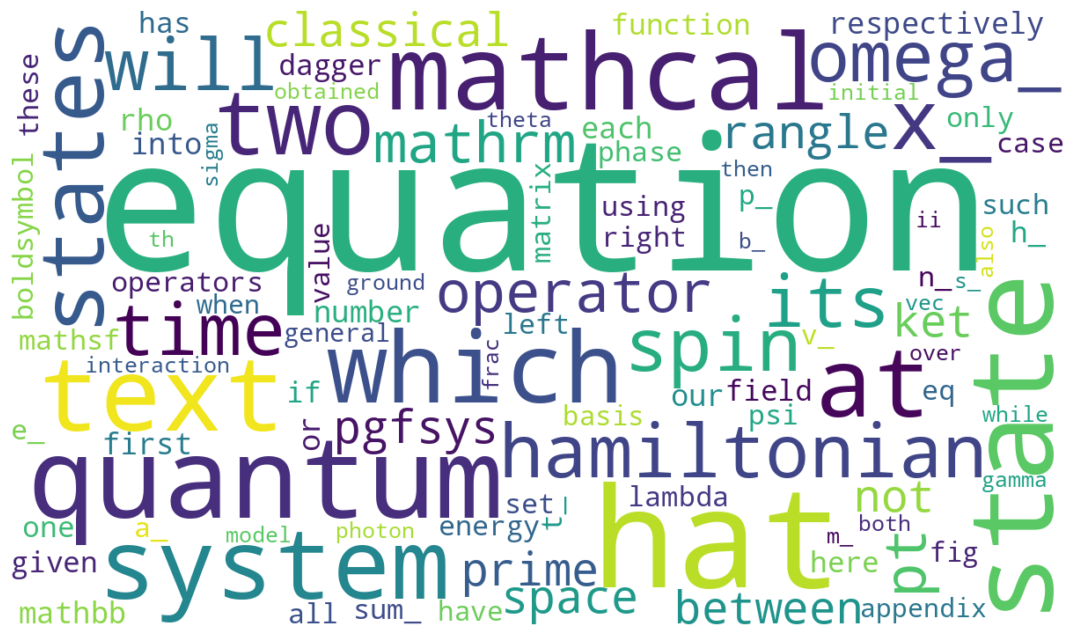

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    colormap="viridis",
    max_words=100,
).generate_from_frequencies(counter)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [17]:
import json
import re
from pathlib import Path
from collections import Counter

# Connect to the extracted equations database for the Equations Knowledge Graph
input_file = Path("../../data/3_equations.json")

data = json.loads(input_file.read_text(encoding="utf-8"))

counter = Counter()

for paper_equations in data.values():
    for entry in paper_equations.values():
        window = entry.get("surrounding_text", {}).get("window", "")
        
        # Match words with at least 2 characters to filter out single-letter variables
        words = re.findall(r"[A-Za-z][A-Za-z0-9_\\-]{1,}", window.lower())
        
        # Filter individual tokens against standard vocabulary stopwords
        
        # Construct bigrams (pairs of adjacent words)
        # zip(words, words[1:]) pairs word[0] with word[1], word[1] with word[2], etc.
        bigrams = [f"{w1} {w2}" for w1, w2 in zip(words, words[1:])]
        
        counter.update(bigrams)

# Display the 50 most common word pairs to discover anchor nodes for the Equations Knowledge Graph
print("--- 50 Most Common Bigrams ---")
for bigram, freq in counter.most_common(50):
    print(f"{bigram}: {freq}")

--- 50 Most Common Bigrams ---
of the: 456
in the: 244
is the: 201
to the: 138
and the: 125
equation where: 116
can be: 85
on the: 82
for the: 77
by the: 59
from the: 58
with the: 57
that the: 56
as the: 55
are the: 54
in this: 49
hat rho: 46
pt pt: 46
we will: 45
where the: 43
the system: 38
at the: 37
number of: 36
the first: 30
it is: 30
given by: 29
and is: 29
ground state: 29
in fig: 29
to be: 28
hilbert space: 28
hat dagger: 28
the two: 27
the ground: 27
hat text: 27
the hamiltonian: 27
note that: 26
state of: 26
hat hat: 26
equation in: 25
set of: 25
the corresponding: 25
which is: 24
the total: 24
with respect: 24
respect to: 24
in appendix: 24
in eq: 23
between the: 23
the initial: 23


In [18]:
counter.most_common()

[('of the', 456),
 ('in the', 244),
 ('is the', 201),
 ('to the', 138),
 ('and the', 125),
 ('equation where', 116),
 ('can be', 85),
 ('on the', 82),
 ('for the', 77),
 ('by the', 59),
 ('from the', 58),
 ('with the', 57),
 ('that the', 56),
 ('as the', 55),
 ('are the', 54),
 ('in this', 49),
 ('hat rho', 46),
 ('pt pt', 46),
 ('we will', 45),
 ('where the', 43),
 ('the system', 38),
 ('at the', 37),
 ('number of', 36),
 ('the first', 30),
 ('it is', 30),
 ('given by', 29),
 ('and is', 29),
 ('ground state', 29),
 ('in fig', 29),
 ('to be', 28),
 ('hilbert space', 28),
 ('hat dagger', 28),
 ('the two', 27),
 ('the ground', 27),
 ('hat text', 27),
 ('the hamiltonian', 27),
 ('note that', 26),
 ('state of', 26),
 ('hat hat', 26),
 ('equation in', 25),
 ('set of', 25),
 ('the corresponding', 25),
 ('which is', 24),
 ('the total', 24),
 ('with respect', 24),
 ('respect to', 24),
 ('in appendix', 24),
 ('in eq', 23),
 ('between the', 23),
 ('the initial', 23),
 ('and hat', 23),
 ('obtaine

In [22]:
# Extract all non-empty equation meaning and it's window context in 4_equation_meanings.json
# Export it in the format { "paper_id": { "equation_key": { "meaning": str, "window": str } } }

from pathlib import Path
import json

input_file = Path("../../data/4_equation_meanings.json")
output_file = Path("analysis_meaning.json")

data = json.loads(input_file.read_text(encoding="utf-8"))

exported = {}

for paper_id, equations in data.items():
    paper_output = {}

    for equation_key, entry in equations.items():
        meaning = entry.get("meaning", "").strip()
        if not meaning:
            continue

        window = entry.get("surrounding_text", {}).get("window", "")
        paper_output[equation_key] = {
            "meaning": meaning,
            "window": window,
        }

    if paper_output:
        exported[paper_id] = paper_output

output_file.write_text(
    json.dumps(exported, indent=2, ensure_ascii=False) + "\n",
    encoding="utf-8",
)

print(f"Exported {sum(len(eqs) for eqs in exported.values())} equations")
print(f"Wrote {output_file}")

Exported 83 equations
Wrote analysis_meaning.json
